Importing Libraries and LLM Setup

In [1]:
from langchain_core.prompts import PromptTemplate
from pydantic import BaseModel, Field
from typing import TypedDict, List, Dict, Optional, Literal
from langgraph.graph import StateGraph, END

In [ ]:
import os
import sys
sys.path.append(os.path.abspath(".."))

In [ ]:
from agent.llm import call_llm, call_structured_llm
from agent.states import GlobalState

### Planning Stage
1. Architecture Node: Synthesizes requirements and constraints into a high-level system design.
2. User Checkpoint Node: Allows user to review and modify the proposed architecture.
2. Tech Stack Node: Recommends technologies based on the architecture and constraints.

In [3]:
# ======== Planning Graph States ========

class PlanningState(GlobalState):
    arch_approved: Optional[bool]
    arch_changes_requested: Optional[str]

In [4]:
# ========== Architecture Node ==========

# Structured output schema for architecture design
class ArchitectureDesign(BaseModel):
    pattern: Literal["monolith", "modular_monolith", "microservices"]
    modules: List[str] = Field(default_factory=list, description="List of key modules/components in the architecture")
    reasoning: str = Field("", description="Short Explanation of why this architecture was chosen and others were rejected")
    confidence: float = 0.0

class ArchitectureOutput(BaseModel):
    architecture: ArchitectureDesign

# Prompt template for architecture design
architecture_prompt = PromptTemplate.from_template(
    """You are a senior system architect.
Design the system architecture from requirements and constraints. If previous architecture exists, change it based on requested changes.

Return practical and concise output grounded in the input.

Requirements:
{requirements}

Constraints:
{constraints}

Previous architecture:
{architecture}

Changes requested:
{arch_changes_requested}"""
)

# Node function for architecture design
def architecture_node(state: PlanningState) -> Dict:
    prompt = architecture_prompt.format(
        requirements=state.get("requirements", {}),
        constraints=state.get("constraints", {}),
        architecture=state.get("architecture", {}),
        arch_changes_requested=state.get("arch_changes_requested", ""),
    )
    result = call_structured_llm(ArchitectureOutput, prompt)

    return {
        "architecture": result.get("architecture", {}),
        "arch_approved": None,
        "arch_changes_requested": None,
    }

In [ ]:
# Example usage
architecture_node({
    "requirements": {
        "problem": "Build a social media app for pet owners.",
        "users": ["pet owners"],
        "features": ["pet profiles", "photo sharing", "social connections"],
        "scale_hint": "10,000 daily active users",
        "domain": "social media"
    },
    "constraints": {
        "scale": "10,000 daily active users",
        "latency": "unknown",
        "budget": "unknown",
        "team_size": "unknown",
        "security": "unknown"
    }
})

{'architecture': {'pattern': 'modular_monolith',
  'modules': ['User Authentication',
   'Pet Profiles',
   'Photo/Video Upload & Storage',
   'Feed Generation',
   'Social Connections (Follow/Friend)',
   'Notifications'],
  'reasoning': 'A modular monolith is suitable for the initial scale of 10,000 daily active users. It provides better organization than a traditional monolith and is simpler to manage than microservices at this stage. The modules are distinct but can coexist within a single deployable unit. Microservices would introduce unnecessary complexity and operational overhead for this user base. A full monolith might become difficult to manage as features grow.',
  'confidence': 0.9},
 'arch_approved': None,
 'arch_changes_requested': None}

In [9]:
# ========== User Checkpoint Node ==========

def user_checkpoint_node(state: PlanningState) -> Dict:
    # In a real implementation, this would involve user interaction.
    # For this example, we will simulate user approval.
    print("Proposed Architecture:", state.get("architecture", {}))
    
    # Simulate user approval (in real case, get actual user input)
    user_approval = input("Do you approve this architecture? (yes/no): ").strip().lower() == "yes"

    arch_patterns = ["monolith", "modular_monolith", "microservices"]

    if not user_approval:
        current_arch = state.get("architecture", {}).get("pattern", "unknown")
        arch_alts = [alt for alt in arch_patterns if alt != current_arch]
        changes_requested = input(f"Please suggest changes or pick an alternative from {arch_alts}: ")

        return {
            "arch_approved": False,
            "arch_changes_requested": changes_requested
        }
    
    return {
        "arch_approved": True,
        "arch_changes_requested": None
    }

In [ ]:
# ========= Tech Stack Node ==========

# Structured output schema for tech stack selection
class FrontendStack(BaseModel):
    language: str = Field(default="", description="Primary frontend language")
    framework: str = Field(default="", description="Frontend framework or library")
    reasoning: str = Field(default="", description="Why this frontend choice fits the system")

class BackendStack(BaseModel):
    language: str = Field(default="", description="Primary backend language")
    framework: str = Field(default="", description="Backend framework or runtime")
    api_style: str = Field(default="", description="API style such as REST or GraphQL if applicable")
    reasoning: str = Field(default="", description="Why this backend choice fits the system")

class DatabaseStack(BaseModel):
    type: str = Field(default="", description="Database category such as relational or document")
    name: str = Field(default="", description="Recommended database product")
    orm: str = Field(default="", description="ORM framework if database is relational and backend requires it")
    reasoning: str = Field(default="", description="Why this database choice fits the system")

class InfraStack(BaseModel):
    provider: str = Field(default="", description="Cloud or platform provider")
    services: List[str] = Field(default_factory=list, description="Core infrastructure services")
    reasoning: str = Field(default="", description="Why this infrastructure choice fits the system")

class TechStackDetails(BaseModel):
    frontend: FrontendStack = Field(default_factory=FrontendStack)
    backend: BackendStack = Field(default_factory=BackendStack)
    database: DatabaseStack = Field(default_factory=DatabaseStack)
    infra: InfraStack = Field(default_factory=InfraStack)
    overall_reasoning: str = Field(default="", description="How the tech stack fit the architecture as a whole")
    confidence: float = Field(default=0.0, ge=0.0, le=1.0, description="Overall confidence from 0 to 1")

class TechStackOutput(BaseModel):
    tech_stack: TechStackDetails

# Prompt template for tech stack selection
tech_prompt = PromptTemplate.from_template(
    """You are a senior system architect.
Select a suitable tech stack based on architecture and constraints.

Return practical and concise output grounded in the input.
Use nested objects for frontend, backend, database, and infra. Keep confidence between 0 and 1.

Architecture:
{architecture}

Constraints:
{constraints}"""
)

# Node function for tech stack selection
def tech_node(state: PlanningState) -> Dict:
    prompt = tech_prompt.format(
        architecture=state.get("architecture", {}),
        constraints=state.get("constraints", {}),
    )
    result = call_structured_llm(TechStackOutput, prompt)

    return {
        "tech_stack": result.get("tech_stack", {}),
    }

In [11]:
# Example usage
tech_node({
    'architecture': {'pattern': 'Microservices Architecture',
      'modules': ['User Authentication',
      'Pet Profile Management',
      'Photo Upload and Storage',
      'Social Feed',
      'Connections (Friends/Followers)',
      'Notifications'],
      'reasoning': 'A microservices architecture is suitable for this social media app due to its scalability, flexibility, and maintainability. It allows individual components like user authentication, pet profiles, and photo sharing to be developed, deployed, and scaled independently. This is crucial for handling 10,000 daily active users and potential future growth. The modular nature also facilitates easier updates and integration of new features.',
      'alternatives': ['Real-time Chat',
      'Event Planning',
      'Grooming Service Integration'],
      'confidence': 0.8
    },
    "constraints": {
        "scale": "10,000 daily active users",
        "latency": "unknown",
        "budget": "unknown",
        "team_size": "unknown",
        "security": "unknown"
    }
})

{'tech_stack': {'frontend': {'language': 'TypeScript',
   'framework': 'React',
   'reasoning': 'React allows for efficient UI development and management of complex state, suitable for a dynamic social media feed and profiles. TypeScript enhances maintainability and scalability for a growing application.'},
  'backend': {'language': 'Python',
   'framework': 'FastAPI',
   'reasoning': 'Python with FastAPI offers excellent performance, rapid development, and built-in support for asynchronous operations, which is beneficial for microservices handling multiple requests like photo uploads and notifications. Its extensive libraries also support various functionalities.'},
  'database': {'type': 'Document',
   'name': 'MongoDB',
   'orm': '',
   'reasoning': 'MongoDB is a flexible NoSQL database well-suited for evolving data structures common in social media apps, such as user profiles and feed content. Its scalability and performance can handle the demands of 10,000 daily active users.'},
 

In [12]:
# =========== Planning Router Nodes ===========

def planning_checkpoint_router(state: PlanningState):
    if state.get("arch_approved", True):
        return "approved"
    else:
        return "changes"

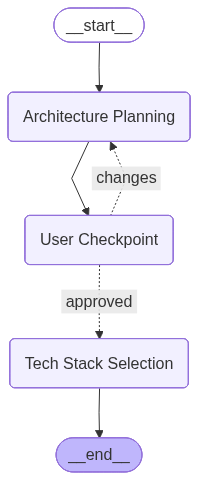

In [13]:
# ========== Graph Construction ==========

planning_graph = StateGraph(PlanningState)

planning_graph.add_node("Architecture Planning", architecture_node)
planning_graph.add_node("User Checkpoint", user_checkpoint_node)
planning_graph.add_node("Tech Stack Selection", tech_node)

planning_graph.add_conditional_edges(
    "User Checkpoint",
    planning_checkpoint_router,
    {
        "changes": "Architecture Planning",
        "approved": "Tech Stack Selection"
    }
)

planning_graph.set_entry_point("Architecture Planning")
planning_graph.add_edge("Architecture Planning", "User Checkpoint")
planning_graph.add_edge("Tech Stack Selection", END)

planning_stage = planning_graph.compile()
planning_stage

In [ ]:
# Example usage of the planning stage
planning_stage.invoke({
    "requirements": {
        "problem": "Build a social media app for pet owners.",
        "users": ["pet owners"],
        "features": ["pet profiles", "photo sharing", "social connections"],
        "scale_hint": "10,000 daily active users",
        "domain": "social media"
    },
    "constraints": {
        "scale": "10,000 daily active users",
        "latency": "unknown",
        "budget": "unknown",
        "team_size": "unknown",
        "security": "unknown"
    }
})

Proposed Architecture: {'pattern': 'modular_monolith', 'modules': ['User authentication', 'Pet profiles', 'Photo uploading and storage', 'Feed generation', 'Social connections (following/followers)'], 'reasoning': 'A modular monolith is suitable for the initial scale of 10,000 daily active users. It allows for a single deployment unit while maintaining internal separation of concerns, which can be beneficial for development and future scaling. Microservices would be an over-complication at this stage, and a pure monolith might become difficult to manage as the application grows.', 'confidence': 0.8}
Proposed Architecture: {'pattern': 'monolith', 'modules': ['User authentication', 'Pet profiles', 'Photo uploading and storage', 'Feed generation', 'Social connections (following/followers)'], 'reasoning': "The user requested a change to a monolithic architecture. While a modular monolith was previously recommended for 10,000 daily active users, a pure monolith can also be suitable for this

{'requirements': {'problem': 'Build a social media app for pet owners.',
  'users': ['pet owners'],
  'features': ['pet profiles', 'photo sharing', 'social connections'],
  'scale_hint': '10,000 daily active users',
  'domain': 'social media'},
 'constraints': {'scale': '10,000 daily active users',
  'latency': 'unknown',
  'budget': 'unknown',
  'team_size': 'unknown',
  'security': 'unknown'},
 'architecture': {'pattern': 'monolith',
  'modules': ['User authentication',
   'Pet profiles',
   'Photo uploading and storage',
   'Feed generation',
   'Social connections (following/followers)'],
  'reasoning': "The user requested a change to a monolithic architecture. While a modular monolith was previously recommended for 10,000 daily active users, a pure monolith can also be suitable for this scale if the team prioritizes rapid development and a simpler deployment process. It's important to note that as the application grows beyond this initial scale, refactoring to a modular monolith o